# Can We Predict Who Wins a UFC Fight?

This notebook tries to guess the winner of a UFC fight, Red corner or Blue corner, using only facts we'd know before the fight: each fighter's record, age, reach, recent form, and so on. The model never sees anything that happens during or after the fight.

We dropped the 5 draws and 3 no-contests from the data. That leaves a clean two-way choice: Red or Blue.

Before judging any model, we need something to compare it against. We use two simple yardsticks:

- **Always pick Red.** The Red corner wins more often in UFC history, about 58% of the time.
- **Always pick whoever the betting markets favor.** Sportsbooks already do a lot of this prediction work through their odds.

If a model can't beat the second yardstick, it isn't telling us anything the betting markets don't already know.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("ufc-master.csv")
print("Shape:", df.shape)
print()
print(df["Winner"].value_counts(dropna=False))
df.head()


Shape: (7177, 118)

Winner
Red           4145
Blue          3024
Draw             5
No Contest       3
Name: count, dtype: int64


,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,...,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,False,Middleweight,MALE,5,0,3,0,3.52,0.44,0.9,1.45,0.30,4,2,18,0,0,0,1,4,2,0,7,Orthodox,187.96,190.50,185,3,0,0,4.03,0.48,0.1,0.05,0.09,9,5,66,12,0,...,-12,-1,2,-5.08,-12.70,-7,-0.51,0.8,1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,False,Women's Flyweight,FEMALE,3,0,7,0,4.56,0.53,0.1,1.56,0.45,7,2,34,0,0,2,4,5,0,0,11,Switch,165.10,165.10,125,2,0,1,4.11,0.41,0.7,0.40,0.35,5,5,45,3,0,...,-3,5,-2,0.00,-2.54,-5,0.45,-0.6,1.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,False,Welterweight,MALE,3,3,0,0,5.11,0.43,0.6,1.06,0.30,2,10,40,0,0,0,2,4,2,0,8,Orthodox,182.88,193.04,170,0,3,0,2.02,0.40,1.0,3.11,0.47,4,7,47,1,0,...,-1,4,-6,-2.54,2.54,-2,3.09,-0.4,-2.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUB,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,False,Featherweight,MALE,3,0,1,0,8.67,0.64,0.0,0.00,0.00,1,0,1,0,0,0,0,1,0,0,1,Orthodox,175.26,182.88,145,1,0,0,6.18,0.48,0.7,1.73,0.43,3,8,36,0,0,...,0,-2,-4,-10.16,-5.08,-6,2.49,-0.7,-1.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,False,Middleweight,MALE,3,0,2,0,6.10,0.64,0.0,0.29,1.00,2,1,9,0,0,0,0,2,0,0,2,Orthodox,198.12,200.66,185,0,4,1,3.28,0.44,0.3,1.65,0.41,3,0,9,0,0,...,0,-1,-1,10.16,-2.54,5,2.82,-0.3,-1.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
df = df[df["Winner"].isin(["Red", "Blue"])].copy()
df["target"] = (df["Winner"] == "Red").astype(int)

print(f"Rows after dropping Draw/No Contest: {len(df)}")
print(df["target"].value_counts(normalize=True).rename({1: "Red", 0: "Blue"}))


Rows after dropping Draw/No Contest: 7169
target
Red     0.578184
Blue    0.421816
Name: proportion, dtype: float64


## Checking for a cheat code hiding in the data

The dataset includes columns that count how many times each fighter has won by knockout, submission, and so on. Those counts should only reflect fights before the one we're trying to predict. If they secretly include the result of the current fight, the model could cheat: instead of learning anything real, it would just read the answer off a column.

The check below tests for that. We remove these columns in the next step either way. This cell exists so you can see why.

In [4]:
red_ko_win = df[(df["Winner"] == "Red") & (df["finish"] == "KO/TKO")]
other_ko = df[~((df["Winner"] == "Red") & (df["finish"] == "KO/TKO"))]
print("Mean R_win_by_KO/TKO | Red won by KO/TKO this fight:", red_ko_win["R_win_by_KO/TKO"].mean())
print("Mean R_win_by_KO/TKO | otherwise:                  ", other_ko["R_win_by_KO/TKO"].mean())

red_sub_win = df[(df["Winner"] == "Red") & (df["finish"] == "SUB")]
other_sub = df[~((df["Winner"] == "Red") & (df["finish"] == "SUB"))]
print()
print("Mean R_win_by_Submission | Red won by SUB this fight:", red_sub_win["R_win_by_Submission"].mean())
print("Mean R_win_by_Submission | otherwise:                ", other_sub["R_win_by_Submission"].mean())
print()
print("=> Higher means in the 'this fight' rows confirm the counters include the current fight's")
print("   own result, i.e. they are post-fight leakage. Dropping them next regardless.")


Mean R_win_by_KO/TKO | Red won by KO/TKO this fight: 2.0193236714975846
Mean R_win_by_KO/TKO | otherwise:                   1.5289353804622912

Mean R_win_by_Submission | Red won by SUB this fight: 1.4696774193548388
Mean R_win_by_Submission | otherwise:                 0.8878636221457616

=> Higher means in the 'this fight' rows confirm the counters include the current fight's
   own result, i.e. they are post-fight leakage. Dropping them next regardless.


In [5]:
POST_FIGHT_OUTCOME_LEAKAGE = [
    "finish", "finish_details", "finish_round", "finish_round_time", "total_fight_time_secs",
]
CUMULATIVE_COUNT_LEAKAGE = [
    "R_win_by_Decision_Majority", "R_win_by_Decision_Split", "R_win_by_Decision_Unanimous",
    "R_win_by_KO/TKO", "R_win_by_Submission", "R_win_by_TKO_Doctor_Stoppage",
    "B_win_by_Decision_Majority", "B_win_by_Decision_Split", "B_win_by_Decision_Unanimous",
    "B_win_by_KO/TKO", "B_win_by_Submission", "B_win_by_TKO_Doctor_Stoppage",
]
IDENTITY_COLS = ["R_fighter", "B_fighter", "location", "country"]
# date is kept for now -- needed for the chronological split below

df = df.drop(columns=POST_FIGHT_OUTCOME_LEAKAGE + CUMULATIVE_COUNT_LEAKAGE + IDENTITY_COLS)
print("Shape after dropping leakage/identity columns:", df.shape)


Shape after dropping leakage/identity columns: (7169, 98)


## What the model gets to see, and what we left out

We didn't hand the model every column in the spreadsheet. Here's the reasoning.

**Included**: the 15 columns that already measure the difference between the two fighters (win streaks, reach, age, and more), two more differences we calculated ourselves (striking accuracy and takedown accuracy, since the spreadsheet only lists each fighter's percentage, not the gap between them), how many rounds the fight is scheduled for, and a few categories: title fight or not, weight class, gender, each fighter's stance, and who's ranked higher.

**Left out, on purpose**: raw per-fighter numbers that already have a "difference" version on our list (no need for both), a handful of columns we don't expect to matter much (fight weight in pounds, whether the arena was empty, draws), and 26 columns about division rankings that are almost entirely blank, filled in for only about 2% of fights. None of this is hidden. It's just outside what we're testing here, and worth a second look later.

**Held back entirely**: the betting odds. We use those later, on their own, to see how the model stacks up against the betting market, and in one extra experiment near the end. The main model never gets to see them. A model that needs Vegas's own numbers to make a pick isn't really predicting anything.

In [6]:
# B_Stance has dirty data: blanks + a 'Switch ' (trailing space) distinct from 'Switch'
df["B_Stance"] = df["B_Stance"].str.strip()
df["R_Stance"] = df["R_Stance"].str.strip()
df["B_Stance"] = df["B_Stance"].fillna("Unknown")
df["R_Stance"] = df["R_Stance"].fillna("Unknown")

# better_rank has blanks (no ranked fighter on either side) -> own category
df["better_rank"] = df["better_rank"].fillna("Unknown")

# title_bout is already bool -> numeric 0/1
df["title_bout"] = df["title_bout"].astype(int)

print(df["B_Stance"].value_counts())
print()
print(df["better_rank"].value_counts())


B_Stance
Orthodox       5303
Southpaw       1391
Switch          468
Unknown           6
Open Stance       1
Name: count, dtype: int64

better_rank
neither    4695
Red        1944
Unknown     430
Blue        100
Name: count, dtype: int64


In [7]:
# debut fighters have no recorded attempts yet, so the raw per-corner pct is NaN for them;
# filling the resulting diff with 0 treats "not enough data to compute a percentage" as
# "no measurable difference" -- an explicit choice rather than leaving it for the imputer.
n_sig_str_na = (df["R_avg_SIG_STR_pct"].isna() | df["B_avg_SIG_STR_pct"].isna()).sum()
n_td_na = (df["R_avg_TD_pct"].isna() | df["B_avg_TD_pct"].isna()).sum()

df["avg_sig_str_pct_dif"] = (df["R_avg_SIG_STR_pct"] - df["B_avg_SIG_STR_pct"]).fillna(0)
df["avg_td_pct_dif"] = (df["R_avg_TD_pct"] - df["B_avg_TD_pct"]).fillna(0)

print(f"avg_sig_str_pct_dif: {n_sig_str_na} rows had a missing per-corner pct -> filled with 0")
print(f"avg_td_pct_dif:      {n_td_na} rows had a missing per-corner pct -> filled with 0")
df[["avg_sig_str_pct_dif", "avg_td_pct_dif"]].describe()


avg_sig_str_pct_dif: 887 rows had a missing per-corner pct -> filled with 0
avg_td_pct_dif:      953 rows had a missing per-corner pct -> filled with 0


,avg_sig_str_pct_dif,avg_td_pct_dif
count,7169.000000,7169.000000
mean,0.006625,0.018608
std,0.126798,0.289455
min,-0.570000,-1.000000
25%,-0.060000,-0.130000
50%,0.000000,0.000000
75%,0.066000,0.175000
max,0.820000,1.000000


In [8]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

cutoff_idx = int(np.floor(len(df) * 0.8))
train_df = df.iloc[:cutoff_idx].copy()
test_df = df.iloc[cutoff_idx:].copy()

print(f"Cutoff index: {cutoff_idx} / {len(df)}")
print(f"Train: {len(train_df)} rows, {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"Test:  {len(test_df)} rows, {test_df['date'].min().date()} to {test_df['date'].max().date()}")
print()
print("Train target balance:\n", train_df["target"].value_counts(normalize=True))
print()
print("Test target balance:\n", test_df["target"].value_counts(normalize=True))

if train_df["date"].max() == test_df["date"].min():
    print()
    print(f"NOTE: train and test share a boundary date ({train_df['date'].max().date()}) -- "
          "fights from the same event can land on both sides of the split. Acceptable for "
          "fight-level prediction, but a known limitation (see conclusions).")


Cutoff index: 5735 / 7169
Train: 5735 rows, 2010-03-21 to 2023-06-03
Test:  1434 rows, 2023-06-03 to 2026-03-28

Train target balance:
 target
1    0.58204
0    0.41796
Name: proportion, dtype: float64

Test target balance:
 target
1    0.562762
0    0.437238
Name: proportion, dtype: float64

NOTE: train and test share a boundary date (2023-06-03) -- fights from the same event can land on both sides of the split. Acceptable for fight-level prediction, but a known limitation (see conclusions).


In [9]:
NUMERIC_DIF_COLS = [
    "lose_streak_dif", "win_streak_dif", "longest_win_streak_dif",
    "win_dif", "loss_dif", "total_round_dif", "total_title_bout_dif",
    "ko_dif", "sub_dif", "height_dif", "reach_dif", "age_dif",
    "sig_str_dif", "avg_sub_att_dif", "avg_td_dif",
    "avg_sig_str_pct_dif", "avg_td_pct_dif",
]
NUMERIC_OTHER_COLS = ["title_bout", "no_of_rounds"]
CATEGORICAL_COLS = ["weight_class", "gender", "R_Stance", "B_Stance", "better_rank"]

FEATURE_COLS = NUMERIC_DIF_COLS + NUMERIC_OTHER_COLS + CATEGORICAL_COLS
TARGET_COL = "target"

print(f"{len(FEATURE_COLS)} features: {len(NUMERIC_DIF_COLS)} numeric diffs, "
      f"{len(NUMERIC_OTHER_COLS)} other numeric, {len(CATEGORICAL_COLS)} categorical")

na_counts = df[FEATURE_COLS].isna().sum()
na_counts = na_counts[na_counts > 0]
if len(na_counts):
    print("Columns with remaining NaNs (handled by the pipeline's imputers below):")
    print(na_counts)
else:
    print("No NaNs remain in the feature columns.")


24 features: 17 numeric diffs, 2 other numeric, 5 categorical
No NaNs remain in the feature columns.


In [10]:
numeric_cols = NUMERIC_DIF_COLS + NUMERIC_OTHER_COLS

numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
numeric_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# scaling helps Logistic Regression's coefficients but is a no-op for tree models' splits,
# so a single scaled-numeric preprocessor is reused for all three models for simplicity.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_cols),
    ("cat", categorical_pipeline, CATEGORICAL_COLS),
])


In [11]:
X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

# verify no unseen-in-train categories silently change behavior (handle_unknown='ignore' guards
# against this anyway, but we check explicitly since the split is chronological, not random)
for c in CATEGORICAL_COLS:
    unseen = set(X_test[c].unique()) - set(X_train[c].unique())
    if unseen:
        print(f"{c}: categories in test not seen in train -> {unseen}")
print("(no output above means no unseen categories for this split)")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

pipelines = {
    name: Pipeline([("prep", preprocessor), ("clf", clf)])
    for name, clf in models.items()
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
print("Fitted:", list(pipelines.keys()))


better_rank: categories in test not seen in train -> {'Unknown'}
(no output above means no unseen categories for this split)


Fitted: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [12]:
baseline_always_red_acc = (test_df[TARGET_COL] == 1).mean()
print(f"Baseline -- always predict Red: {baseline_always_red_acc:.4f} accuracy on the test set "
      f"({len(test_df)} rows)")


Baseline -- always predict Red: 0.5628 accuracy on the test set (1434 rows)


In [13]:
def implied_prob(american_odds):
    american_odds = np.asarray(american_odds, dtype=float)
    # np.where evaluates both branches for every element, so the unused branch can divide by
    # zero at odds == -100 (discarded either way) -- suppress the resulting spurious warning.
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(
            american_odds < 0,
            -american_odds / (-american_odds + 100),
            100 / (american_odds + 100),
        )

odds_mask = test_df["R_odds"].notna() & test_df["B_odds"].notna()
odds_test = test_df[odds_mask]

r_prob = implied_prob(odds_test["R_odds"])
b_prob = implied_prob(odds_test["B_odds"])
pred_favorite = (r_prob > b_prob).astype(int)

baseline_favorite_acc = accuracy_score(odds_test[TARGET_COL], pred_favorite)
print(f"Baseline -- always predict betting favorite: {baseline_favorite_acc:.4f} accuracy "
      f"on {odds_mask.sum()} of {len(test_df)} test rows with non-null odds")


Baseline -- always predict betting favorite: 0.6986 accuracy on 1211 of 1434 test rows with non-null odds


=== Logistic Regression ===
Accuracy: 0.6053  ROC-AUC: 0.6292
              precision    recall  f1-score   support

        Blue       0.59      0.33      0.42       627
         Red       0.61      0.82      0.70       807

    accuracy                           0.61      1434
   macro avg       0.60      0.57      0.56      1434
weighted avg       0.60      0.61      0.58      1434



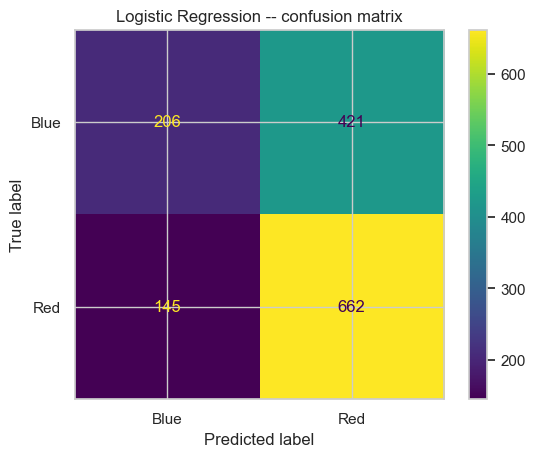

=== Random Forest ===
Accuracy: 0.6388  ROC-AUC: 0.6746
              precision    recall  f1-score   support

        Blue       0.66      0.36      0.47       627
         Red       0.63      0.85      0.73       807

    accuracy                           0.64      1434
   macro avg       0.64      0.61      0.60      1434
weighted avg       0.64      0.64      0.61      1434



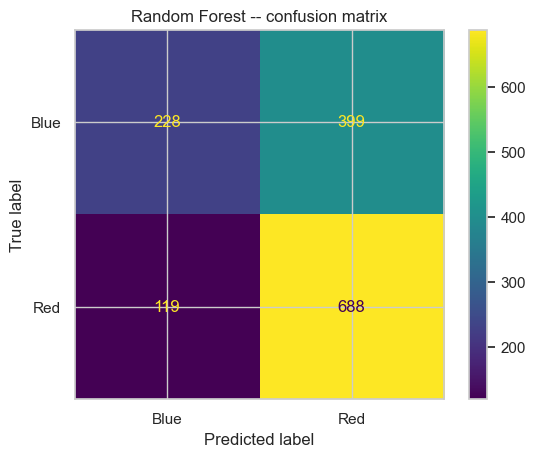

=== Gradient Boosting ===
Accuracy: 0.6213  ROC-AUC: 0.6548
              precision    recall  f1-score   support

        Blue       0.63      0.33      0.43       627
         Red       0.62      0.85      0.72       807

    accuracy                           0.62      1434
   macro avg       0.62      0.59      0.58      1434
weighted avg       0.62      0.62      0.59      1434



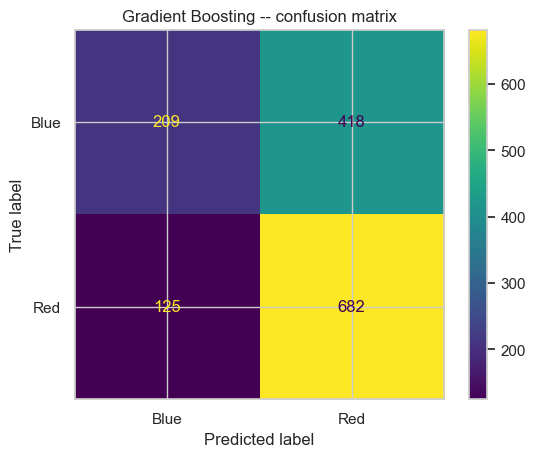

In [14]:
def evaluate(pipe, X, y, name):
    preds = pipe.predict(X)
    probs = pipe.predict_proba(X)[:, 1]
    acc = accuracy_score(y, preds)
    auc = roc_auc_score(y, probs)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}  ROC-AUC: {auc:.4f}")
    print(classification_report(y, preds, target_names=["Blue", "Red"]))
    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=["Blue", "Red"])
    plt.title(f"{name} -- confusion matrix")
    plt.show()
    return {"Method": name, "Accuracy": acc, "ROC-AUC": auc, "N evaluated": len(y)}


model_results = [evaluate(pipe, X_test, y_test, name) for name, pipe in pipelines.items()]


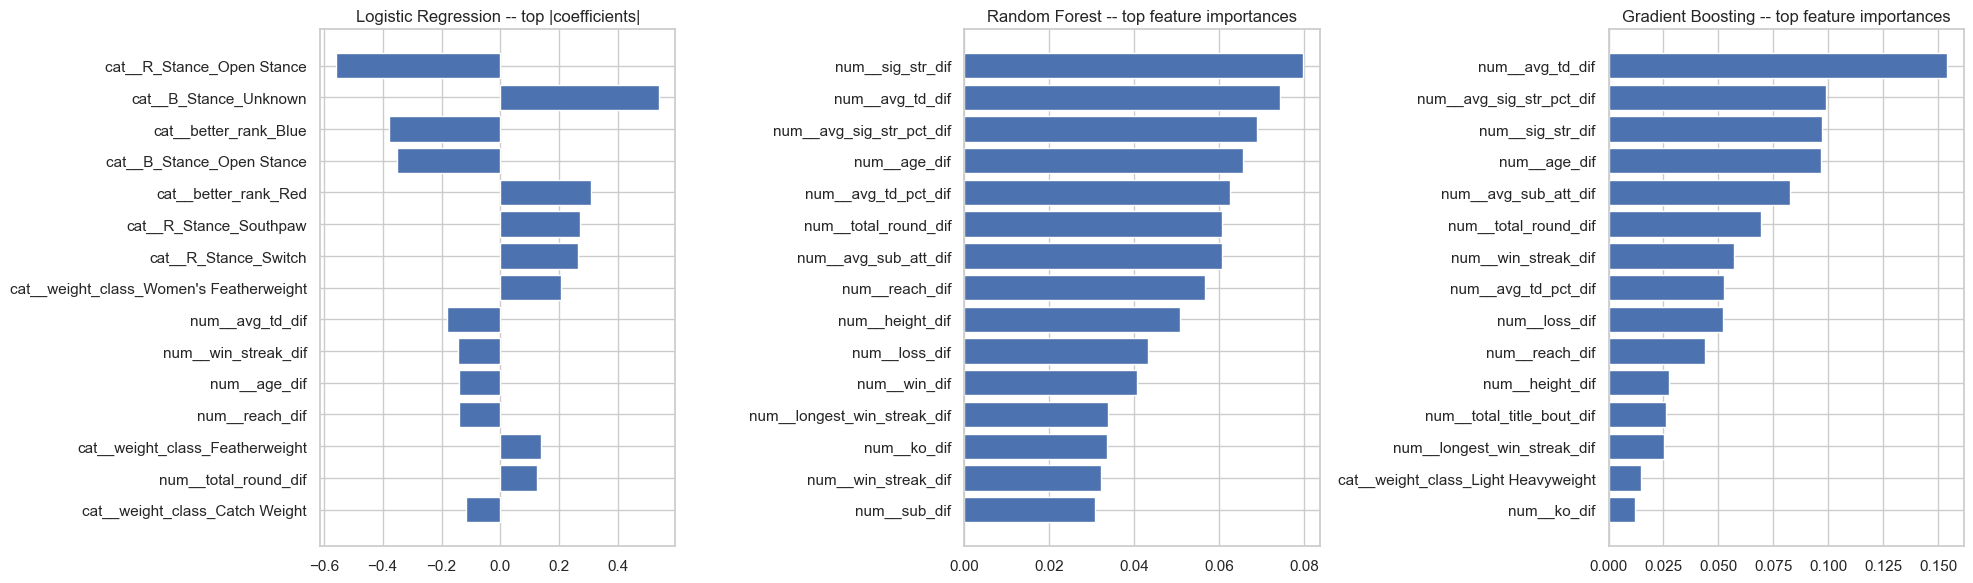

In [15]:
feature_names = pipelines["Logistic Regression"].named_steps["prep"].get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

logreg = pipelines["Logistic Regression"].named_steps["clf"]
coef_order = np.argsort(np.abs(logreg.coef_[0]))[::-1][:15]
axes[0].barh(feature_names[coef_order][::-1], logreg.coef_[0][coef_order][::-1])
axes[0].set_title("Logistic Regression -- top |coefficients|")

for ax, name in zip(axes[1:], ["Random Forest", "Gradient Boosting"]):
    clf = pipelines[name].named_steps["clf"]
    order = np.argsort(clf.feature_importances_)[::-1][:15]
    ax.barh(feature_names[order][::-1], clf.feature_importances_[order][::-1])
    ax.set_title(f"{name} -- top feature importances")

plt.tight_layout()
plt.show()


In [16]:
comparison_rows = [
    {"Method": "Always predict Red", "Accuracy": baseline_always_red_acc, "ROC-AUC": np.nan,
     "N evaluated": len(test_df)},
    {"Method": "Always predict betting favorite", "Accuracy": baseline_favorite_acc, "ROC-AUC": np.nan,
     "N evaluated": int(odds_mask.sum())},
] + model_results

comparison_df = pd.DataFrame(comparison_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
comparison_df


,Method,Accuracy,ROC-AUC,N evaluated
0,Always predict betting favorite,0.698596,NaN,1211
1,Random Forest,0.638773,0.674615,1434
2,Gradient Boosting,0.621339,0.654823,1434
3,Logistic Regression,0.605300,0.629215,1434
4,Always predict Red,0.562762,NaN,1434


Check the table above for two things. Did the model beat "always pick Red"? If so, it learned something beyond the simple fact that Red wins more often. Did it beat "always pick the betting favorite"? That's the harder test, and the one that actually matters: beating the market means the model found something Vegas missed.

## A second experiment: what if we just hand the model the odds?

This isn't a real prediction model, and we're not pretending it is. Betting odds don't exist until the market sets them, so a model trained on odds can't predict anything in advance, it can only look back at numbers that were already public. Treat this section as a ceiling test: if we just give the model the market's own numbers, how much better can it get? We run it completely separately, with its own data and its own results table, so it never gets mixed up with the real model above.

v2 train rows (odds complete): 4501 / 5735
v2 test rows (odds complete):  1128 / 1434


=== Logistic Regression (v2) ===
Accuracy: 0.6959  ROC-AUC: 0.7501
              precision    recall  f1-score   support

        Blue       0.68      0.58      0.62       494
         Red       0.71      0.79      0.74       634

    accuracy                           0.70      1128
   macro avg       0.69      0.68      0.68      1128
weighted avg       0.69      0.70      0.69      1128



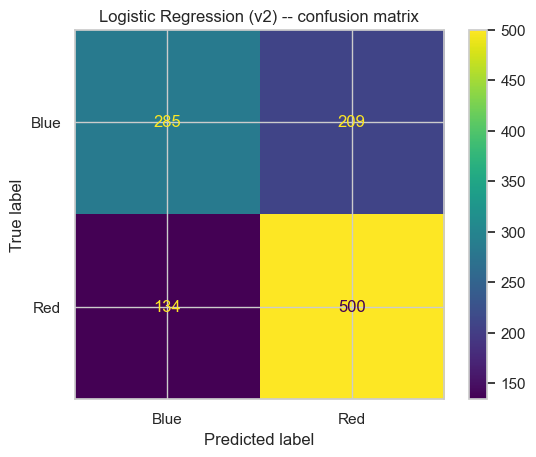

=== Random Forest (v2) ===
Accuracy: 0.7021  ROC-AUC: 0.7612


              precision    recall  f1-score   support

        Blue       0.68      0.61      0.64       494
         Red       0.72      0.78      0.75       634

    accuracy                           0.70      1128
   macro avg       0.70      0.69      0.69      1128
weighted avg       0.70      0.70      0.70      1128



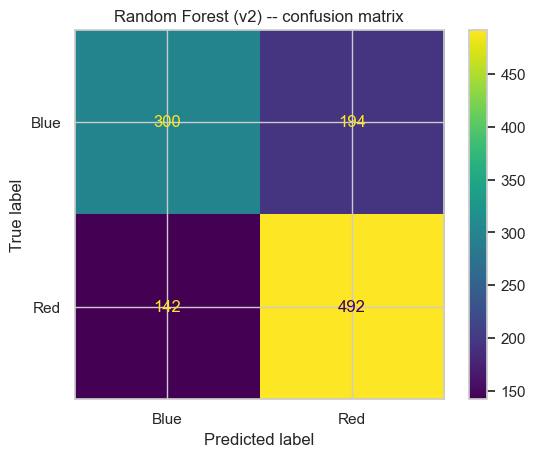

=== Gradient Boosting (v2) ===
Accuracy: 0.6844  ROC-AUC: 0.7385
              precision    recall  f1-score   support

        Blue       0.65      0.60      0.63       494
         Red       0.71      0.75      0.73       634

    accuracy                           0.68      1128
   macro avg       0.68      0.68      0.68      1128
weighted avg       0.68      0.68      0.68      1128



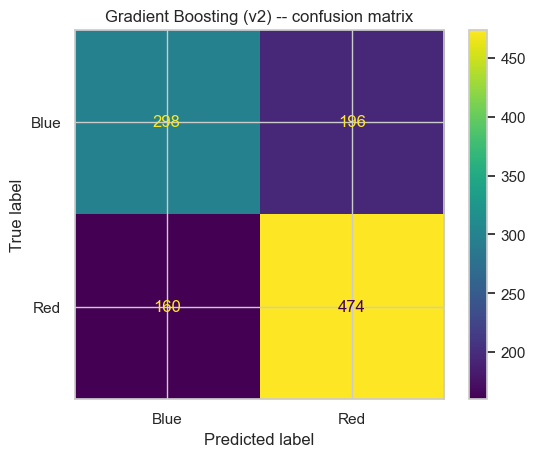

,Method,Accuracy,ROC-AUC,N evaluated
0,Random Forest (v2),0.702128,0.761244,1128
1,Logistic Regression (v2),0.695922,0.750121,1128
2,Always predict betting favorite (v2 subset),0.695922,NaN,1128
3,Gradient Boosting (v2),0.684397,0.738512,1128
4,Always predict Red (v2 subset),0.562057,NaN,1128


In [17]:
ODDS_COLS = [
    "R_odds", "B_odds", "R_ev", "B_ev",
    "r_ko_odds", "r_sub_odds", "r_dec_odds",
    "b_ko_odds", "b_sub_odds", "b_dec_odds",
]
FEATURE_COLS_V2 = FEATURE_COLS + ODDS_COLS

odds_complete_mask_train = train_df[ODDS_COLS].notna().all(axis=1)
odds_complete_mask_test = test_df[ODDS_COLS].notna().all(axis=1)

X_train_v2 = train_df.loc[odds_complete_mask_train, FEATURE_COLS_V2]
y_train_v2 = train_df.loc[odds_complete_mask_train, TARGET_COL]
X_test_v2 = test_df.loc[odds_complete_mask_test, FEATURE_COLS_V2]
y_test_v2 = test_df.loc[odds_complete_mask_test, TARGET_COL]

print(f"v2 train rows (odds complete): {len(X_train_v2)} / {len(train_df)}")
print(f"v2 test rows (odds complete):  {len(X_test_v2)} / {len(test_df)}")

numeric_cols_v2 = numeric_cols + ODDS_COLS
preprocessor_v2 = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_cols_v2),
    ("cat", categorical_pipeline, CATEGORICAL_COLS),
])

pipelines_v2 = {
    name: Pipeline([("prep", preprocessor_v2), ("clf", clf)])
    for name, clf in {
        "Logistic Regression (v2)": LogisticRegression(max_iter=1000),
        "Random Forest (v2)": RandomForestClassifier(n_estimators=300, random_state=42),
        "Gradient Boosting (v2)": GradientBoostingClassifier(random_state=42),
    }.items()
}

for name, pipe in pipelines_v2.items():
    pipe.fit(X_train_v2, y_train_v2)

v2_results = [evaluate(pipe, X_test_v2, y_test_v2, name) for name, pipe in pipelines_v2.items()]

v2_baseline_acc = (y_test_v2 == 1).mean()

# favorite baseline recomputed on the *same* odds-complete subset as v2, for a fair comparison
r_prob_v2 = implied_prob(test_df.loc[odds_complete_mask_test, "R_odds"])
b_prob_v2 = implied_prob(test_df.loc[odds_complete_mask_test, "B_odds"])
pred_favorite_v2 = (r_prob_v2 > b_prob_v2).astype(int)
v2_favorite_acc = accuracy_score(y_test_v2, pred_favorite_v2)

v2_comparison_df = pd.DataFrame(
    [
        {"Method": "Always predict Red (v2 subset)", "Accuracy": v2_baseline_acc, "ROC-AUC": np.nan,
         "N evaluated": len(y_test_v2)},
        {"Method": "Always predict betting favorite (v2 subset)", "Accuracy": v2_favorite_acc,
         "ROC-AUC": np.nan, "N evaluated": len(y_test_v2)},
    ] + v2_results
).sort_values("Accuracy", ascending=False).reset_index(drop=True)
v2_comparison_df


Don't compare this table line by line with the one above. The fights included are different (only ones with complete odds data), and this version of the model gets a head start the first one never had: the market's own numbers, handed to it directly.

## So, can we predict UFC fights?

Here's what happened when we tested this on the most recent 1,434 fights in the data, everything after June 3, 2023, after training only on older fights.

**Using just fighter stats, no odds**: our best model, a Random Forest, picked the right winner 63.9% of the time. That beats picking Red every single time (56.3%), but loses to picking the betting favorite every time (69.9%). The model learned something real. Fighter stats do carry useful signal. But Vegas still knows more than this model does.

**Using fighter stats plus the betting odds**: the best model jumped to 70.2% accuracy, just barely ahead of the betting favorite (69.6%) on the same set of fights. Giving the model Vegas's own numbers let it match Vegas, not beat it by much.

**The takeaway**: pre-fight stats get you partway there, not all the way. They beat doing nothing, but they don't beat the people setting the odds. If you want a bit more confidence behind a pick, these stats help. If you want to outsmart a sportsbook, you'd need something sharper than this.

**Ideas worth trying next**:
- Look again at the ranking columns and other stats we set aside. There may be useful signal in them.
- Try a more powerful model like XGBoost. It isn't installed in this environment, but it's worth adding.
- Split the data by event date instead of by row count, so fights from the same fight card never end up split across training and test.
- Check whether the model's confidence levels match reality, a step called calibration.
- Test with a rolling window of dates instead of one single split, to see whether performance holds up across different stretches of time.